In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
tcs = yf.download(
    'TCS.NS',
    start='2021-01-01',
    end='2025-12-31'
)

print(tcs.head())

/tmp/ipykernel_14420/2029816343.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tcs = yf.download(
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open   Volume
Ticker           TCS.NS       TCS.NS       TCS.NS       TCS.NS   TCS.NS
Date                                                                   
2021-01-01  2569.268555  2579.578093  2526.056235  2526.933642  2681440
2021-01-04  2666.835693  2676.750439  2580.411070  2588.351650  5113293
2021-01-05  2713.820557  2732.465460  2666.967096  2666.967096  5801309
2021-01-06  2677.408447  2731.807701  2664.861480  2719.962702  3726716
2021-01-07  2661.000977  2703.160441  2632.441325  2698.027523  3717827


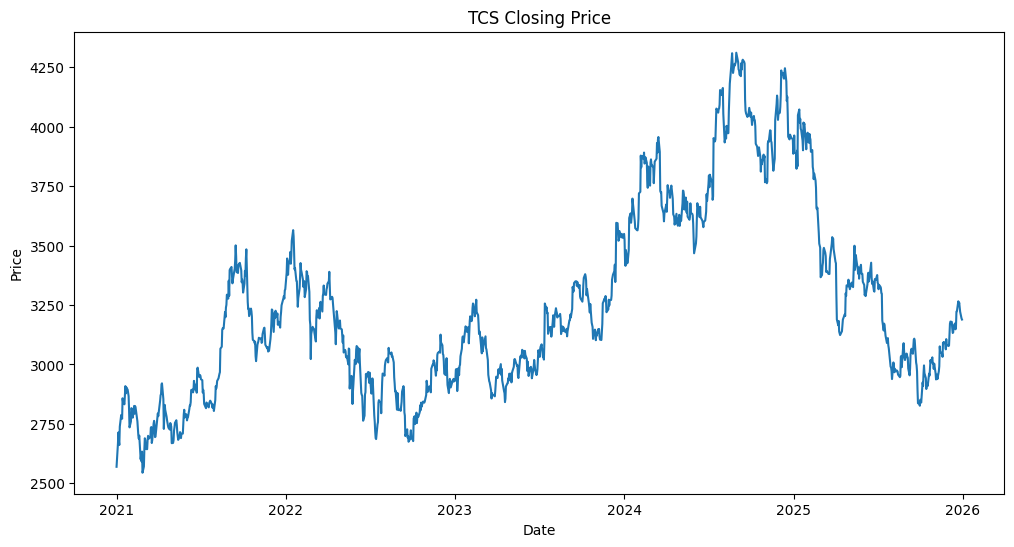

In [4]:
plt.figure(figsize=(12,6))

plt.plot(tcs['Close'])

plt.title('TCS Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

In [5]:
stocks = [
    'TCS.NS',
    'HDFCBANK.NS',
    'ITC.NS',
    'SUNPHARMA.NS',
    'TATAMOTORS.NS'
]

data = {}

for stock in stocks:
    df = yf.download(
        stock,
        start='2021-01-01',
        end='2025-12-31'
    )

    data[stock] = df

print("All Data Downloaded")

/tmp/ipykernel_14420/3097668095.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_14420/3097668095.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_14420/3097668095.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_14420/3097668095.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_14420/3097668095.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
ERROR:yfinance:HTTP Error 404: {"quoteS

All Data Downloaded


In [9]:
data['HDFCBANK.NS'].head()

Price,Close,High,Low,Open,Volume
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
Date,,,,,
2021-01-01,674.886292,683.387169,672.778791,681.966406,8810938
2021-01-04,670.600342,681.019274,662.549349,681.019274,15740192
2021-01-05,675.667725,677.585778,667.285243,672.115816,14386824
2021-01-06,672.755127,681.966386,669.226863,679.598447,22134050
2021-01-07,670.718750,678.461899,668.966498,678.414552,19894842


In [10]:
data['TCS.NS'].to_csv('TCS_Data.csv')

Data Cleaning and Reprocessing

In [11]:
for stock in data:
    print(stock)
    print(data[stock].isnull().sum())
    print("----------------")

TCS.NS
Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64
----------------
HDFCBANK.NS
Price   Ticker     
Close   HDFCBANK.NS    0
High    HDFCBANK.NS    0
Low     HDFCBANK.NS    0
Open    HDFCBANK.NS    0
Volume  HDFCBANK.NS    0
dtype: int64
----------------
ITC.NS
Price   Ticker
Close   ITC.NS    0
High    ITC.NS    0
Low     ITC.NS    0
Open    ITC.NS    0
Volume  ITC.NS    0
dtype: int64
----------------
SUNPHARMA.NS
Price   Ticker      
Close   SUNPHARMA.NS    0
High    SUNPHARMA.NS    0
Low     SUNPHARMA.NS    0
Open    SUNPHARMA.NS    0
Volume  SUNPHARMA.NS    0
dtype: int64
----------------
TATAMOTORS.NS
Price      Ticker       
Adj Close  TATAMOTORS.NS    0
Close      TATAMOTORS.NS    0
High       TATAMOTORS.NS    0
Low        TATAMOTORS.NS    0
Open       TATAMOTORS.NS    0
Volume     TATAMOTORS.NS    0
dtype: int64
----------------


In [12]:
for stock in data:
    data[stock].fillna(method='ffill', inplace=True)

print("Missing values handled")

Missing values handled


/tmp/ipykernel_14420/3850010614.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data[stock].fillna(method='ffill', inplace=True)


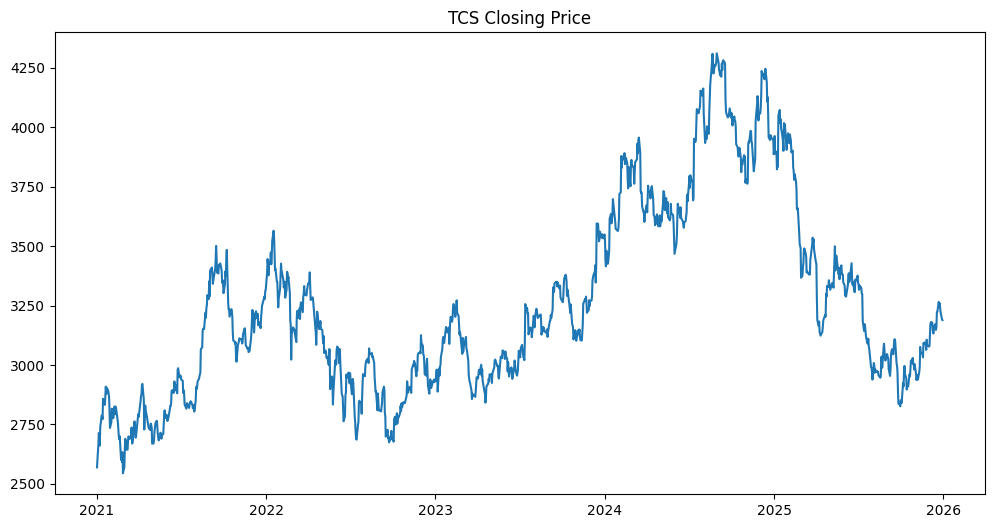

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(data['TCS.NS']['Close'])

plt.title('TCS Closing Price')

plt.show()

In [14]:
!pip install statsmodels

In [15]:
from statsmodels.tsa.stattools import adfuller

In [16]:
result = adfuller(data['TCS.NS']['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.2775663403228825
p-value: 0.17930537473516395


The Data is non-stationary. Apply differencing

In [17]:
data['TCS.NS']['Close_Diff'] = data['TCS.NS']['Close'].diff()

In [18]:
data['TCS.NS'].dropna(inplace=True)

In [19]:
train = data['TCS.NS'][:'2025-06-30']

test = data['TCS.NS']['2025-07-01':]

print(train.shape)
print(test.shape)

(1109, 6)
(125, 6)


Forecasting Model

In [20]:
!pip install statsmodels

ARIMA

In [21]:
from statsmodels.tsa.arima.model import ARIMA

In [22]:
train = data['TCS.NS']['Close'][:'2025-06-30']

test = data['TCS.NS']['Close']['2025-07-01':]

In [23]:
model = ARIMA(train, order=(5,1,0))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [24]:
(5,1,0)

(5, 1, 0)

Train the Model

In [25]:
model_fit = model.fit()

In [26]:
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [27]:
print(forecast)

1109    3376.599652
1110    3375.549495
1111    3375.699520
1112    3375.719968
1113    3375.431826
           ...     
1229    3375.438111
1230    3375.438111
1231    3375.438111
1232    3375.438111
1233    3375.438111
Name: predicted_mean, Length: 125, dtype: float64


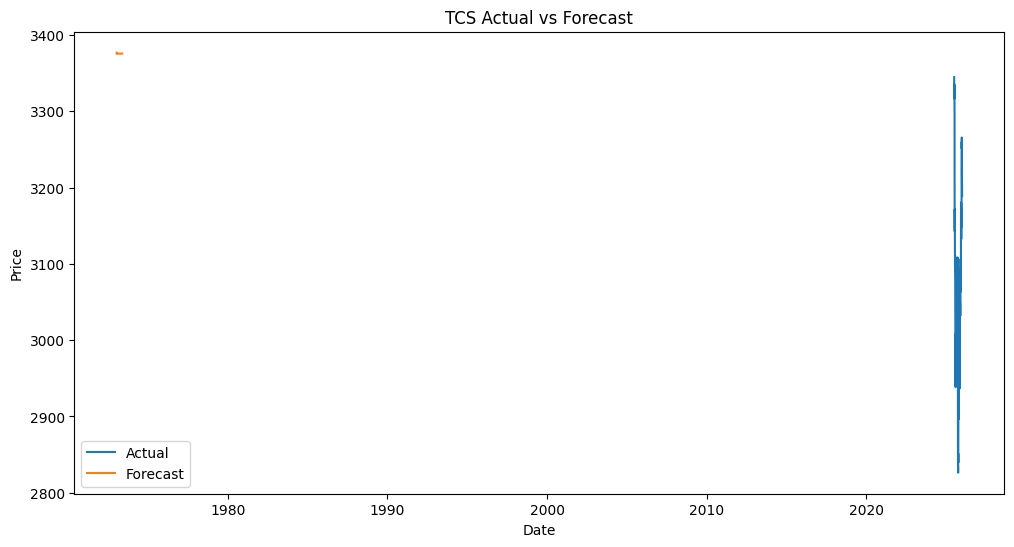

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test, label='Actual')

plt.plot(forecast, label='Forecast')

plt.title('TCS Actual vs Forecast')

plt.xlabel('Date')

plt.ylabel('Price')

plt.legend()

plt.show()

In [29]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [30]:
mape = mean_absolute_percentage_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAPE:", mape)

print("RMSE:", rmse)

MAPE: 0.10539451305489607
RMSE: 338.0858431376993


| Metric | Meaning              |
| ------ | -------------------- |
| MAPE   | prediction error %   |
| RMSE   | forecasting accuracy |
Low=Better

In [31]:
future_forecast = model_fit.forecast(steps=5)

print(future_forecast)

1109    3376.599652
1110    3375.549495
1111    3375.699520
1112    3375.719968
1113    3375.431826
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Volatility

In [33]:
import numpy as np

data['TCS.NS']['Log_Return'] = np.log(
    data['TCS.NS']['Close'] /
    data['TCS.NS']['Close'].shift(1)
)

In [34]:
data['TCS.NS'].head()

Price,Close,High,Low,Open,Volume,Close_Diff,Log_Return
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,,
Date,,,,,,,
2021-01-04,2666.835693,2676.750439,2580.411070,2588.351650,5113293,97.567139,NaN
2021-01-05,2713.820557,2732.465460,2666.967096,2666.967096,5801309,46.984863,NaN
2021-01-06,2677.408447,2731.807701,2664.861480,2719.962702,3726716,-36.412109,NaN
2021-01-07,2661.000977,2703.160441,2632.441325,2698.027523,3717827,-16.407471,NaN
2021-01-08,2738.300049,2744.529726,2684.866036,2711.188252,5879039,77.299072,NaN


In [35]:
data['TCS.NS']['Volatility'] = (
    data['TCS.NS']['Log_Return']
    .rolling(window=20)
    .std()
)

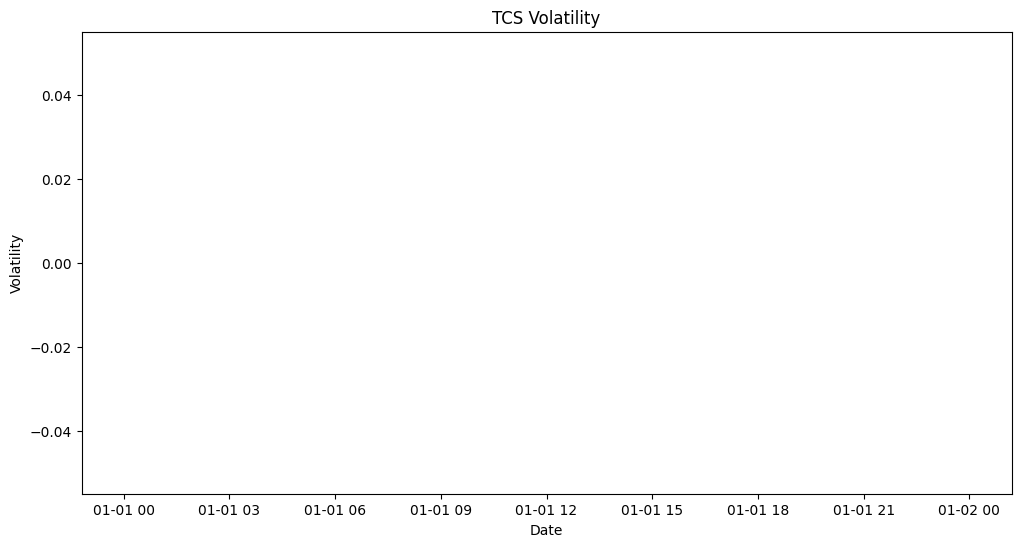

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(data['TCS.NS']['Volatility'])

plt.title('TCS Volatility')

plt.xlabel('Date')

plt.ylabel('Volatility')

plt.show()

In [37]:
data['TCS.NS']['Volatility'].head(30)

,Volatility
Date,
2021-01-04,NaN
2021-01-05,NaN
2021-01-06,NaN
2021-01-07,NaN
2021-01-08,NaN
2021-01-11,NaN
2021-01-12,NaN
2021-01-13,NaN
2021-01-14,NaN


In [38]:
data['TCS.NS'].dropna(inplace=True)

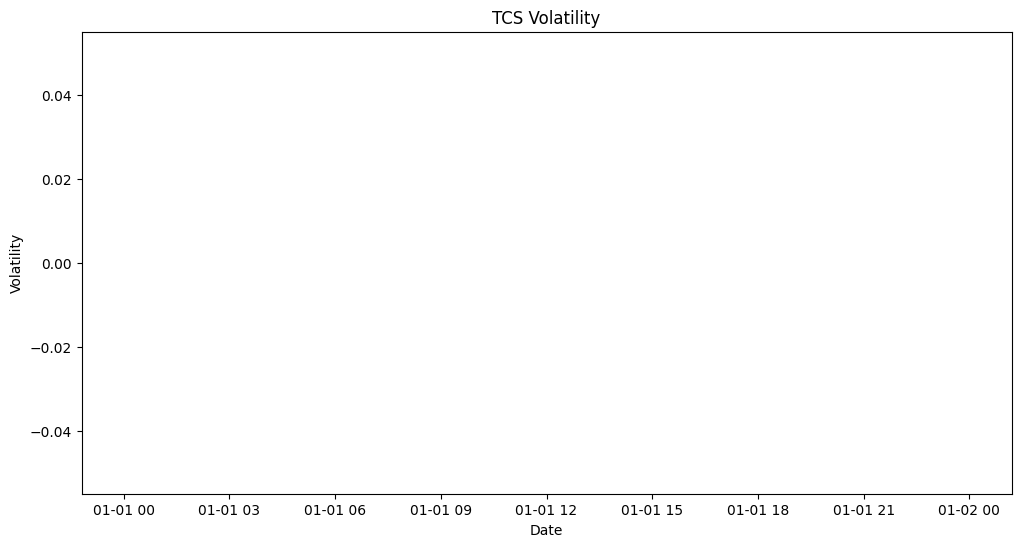

In [39]:
plt.figure(figsize=(12,6))

plt.plot(
    data['TCS.NS'].index,
    data['TCS.NS']['Volatility']
)

plt.title('TCS Volatility')

plt.xlabel('Date')

plt.ylabel('Volatility')

plt.show()

In [52]:
print(data['TCS.NS']['Log_Return'].head(30))

Series([], Name: Log_Return, dtype: float64)


In [53]:
print(data['TCS.NS']['Volatility'].head(40))

Series([], Name: Volatility, dtype: float64)


In [54]:
import yfinance as yf

tcs = yf.download(
    'TCS.NS',
    start='2021-01-01',
    end='2025-12-31'
)

tcs.head()

/tmp/ipykernel_14420/274078389.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tcs = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2021-01-01,2569.268555,2579.578093,2526.056235,2526.933642,2681440
2021-01-04,2666.835693,2676.750439,2580.411070,2588.351650,5113293
2021-01-05,2713.820557,2732.465460,2666.967096,2666.967096,5801309
2021-01-06,2677.408447,2731.807701,2664.861480,2719.962702,3726716
2021-01-07,2661.000977,2703.160441,2632.441325,2698.027523,3717827


In [55]:
import numpy as np

tcs['Log_Return'] = np.log(
    tcs['Close'] / tcs['Close'].shift(1)
)

tcs['Volatility'] = (
    tcs['Log_Return']
    .rolling(20)
    .std()
)

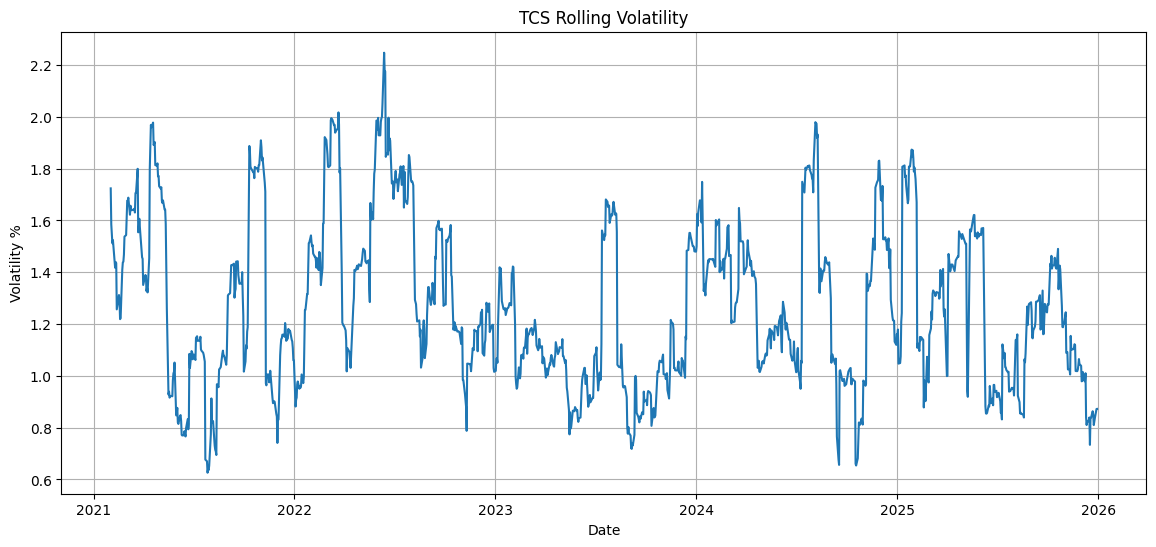

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    tcs.index,
    tcs['Volatility'] * 100
)

plt.title('TCS Rolling Volatility')

plt.xlabel('Date')

plt.ylabel('Volatility %')

plt.grid(True)

plt.show()

In [57]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [59]:
result = seasonal_decompose(
    tcs['Close'],
    model='additive',
    period=30
)

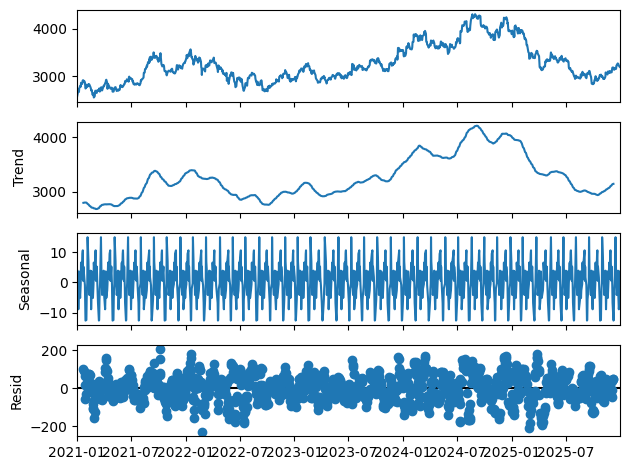

In [71]:
result.plot()
plt.show()

Allocation of all stocks

In [62]:
portfolio = {
    'TCS': 250000,
    'HDFC Bank': 250000,
    'ITC': 200000,
    'Sun Pharma': 150000,
    'Tata Motors': 150000
}

In [63]:
import pandas as pd

portfolio_df = pd.DataFrame(
    portfolio.items(),
    columns=['Stock', 'Investment']
)

portfolio_df

,Stock,Investment
0,TCS,250000
1,HDFC Bank,250000
2,ITC,200000
3,Sun Pharma,150000
4,Tata Motors,150000


In [64]:
portfolio_df['Weight (%)'] = (
    portfolio_df['Investment'] / 1000000
) * 100

portfolio_df

,Stock,Investment,Weight (%)
0,TCS,250000,25.0
1,HDFC Bank,250000,25.0
2,ITC,200000,20.0
3,Sun Pharma,150000,15.0
4,Tata Motors,150000,15.0


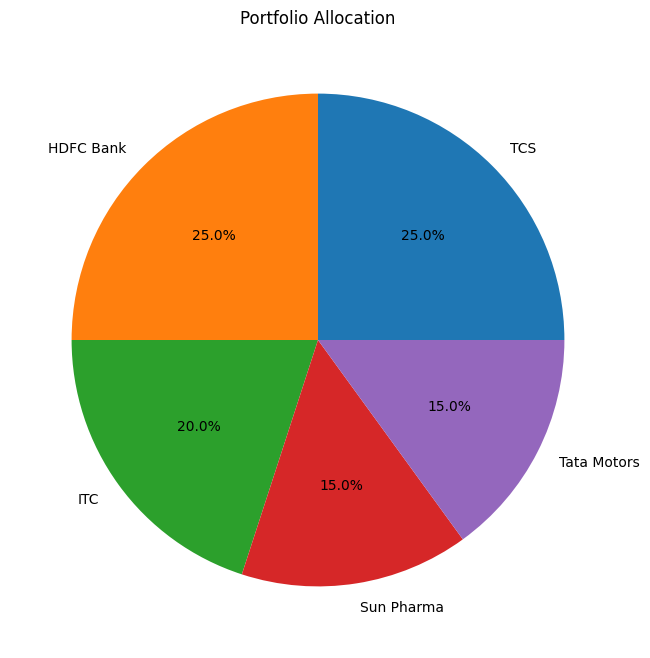

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    portfolio_df['Investment'],
    labels=portfolio_df['Stock'],
    autopct='%1.1f%%'
)

plt.title('Portfolio Allocation')

plt.show()

For Rest of the stocks

In [66]:
from statsmodels.tsa.arima.model import ARIMA

In [67]:
from sklearn.metrics import mean_absolute_percentage_error

import numpy as np

In [68]:
stocks = [
    'TCS.NS',
    'HDFCBANK.NS',
    'ITC.NS',
    'SUNPHARMA.NS',
    'TATAMOTORS.NS'
]

In [69]:
results = {}

In [72]:
for stock in stocks:

    print("Processing:", stock)

    # Download stock data
    df = yf.download(
        stock,
        start='2021-01-01',
        end='2025-12-31'
    )

    # Check if DataFrame is empty due to download failure
    if df.empty:
        print(f"Skipping {stock}: Could not download data or DataFrame is empty.")
        continue

    # Remove missing values
    df.dropna(inplace=True)

    # Train-test split
    train = df['Close'][:'2025-06-30']

    test = df['Close']['2025-07-01':]

    # Check if train or test are empty after splitting and dropping NaNs
    if train.empty or test.empty:
        print(f"Skipping {stock}: Train or test dataset is empty after split/dropna.")
        continue

    # Build ARIMA model
    model = ARIMA(
        train,
        order=(5,1,0)
    )

    # Train model
    model_fit = model.fit()

    # Forecast prices
    forecast = model_fit.forecast(
        steps=len(test)
    )

    # Calculate MAPE
    mape = mean_absolute_percentage_error(
        test,
        forecast
    )

    # Save result
    results[stock] = mape

    print("MAPE:", mape)

/tmp/ipykernel_14420/2868498488.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed

Processing: TCS.NS



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/

MAPE: 0.10551768091885122
Processing: HDFCBANK.NS


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/tmp/ipykernel_14420/2868498488.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

MAPE: 0.01471378135168825
Processing: ITC.NS


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/tmp/ipykernel_14420/2868498488.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

MAPE: 0.02141486756252241
Processing: SUNPHARMA.NS


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/tmp/ipykernel_14420/2868498488.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


MAPE: 0.03279993068444437
Processing: TATAMOTORS.NS
Skipping TATAMOTORS.NS: Could not download data or DataFrame is empty.


In [73]:
results_df = pd.DataFrame(
    results.items(),
    columns=['Stock', 'MAPE']
)

results_df

,Stock,MAPE
0,TCS.NS,0.105518
1,HDFCBANK.NS,0.014714
2,ITC.NS,0.021415
3,SUNPHARMA.NS,0.032800


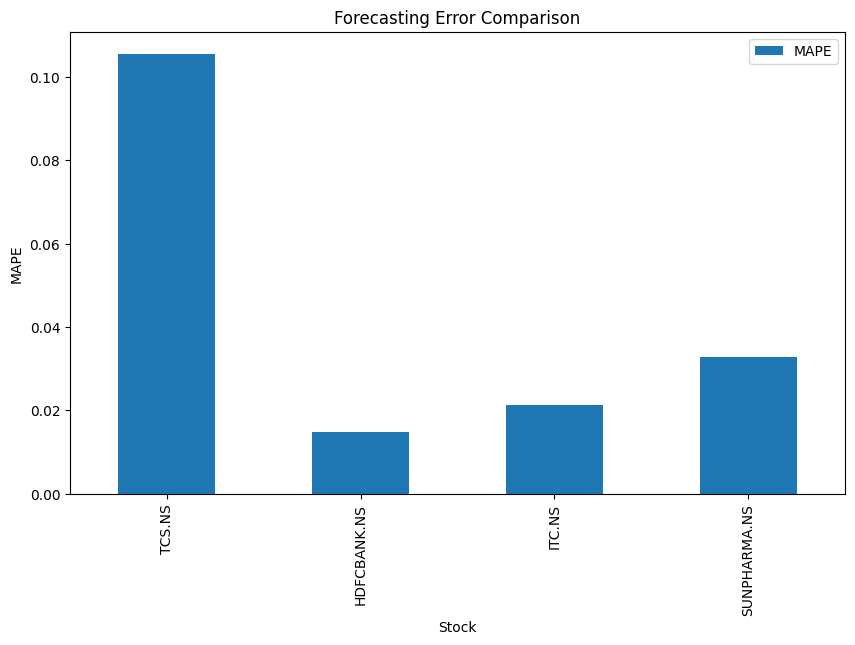

In [74]:
results_df.plot(
    x='Stock',
    y='MAPE',
    kind='bar',
    figsize=(10,6)
)

plt.title('Forecasting Error Comparison')

plt.ylabel('MAPE')

plt.show()

For TATAMOTORS

In [76]:
'TATAMOTORS.NS'

'TATAMOTORS.NS'

In [79]:
df = yf.download(
    'TATAMOTORS.NS',
    start='2021-01-01',
    end='2025-12-31'
)

# Check if DataFrame is empty due to download failure
if df.empty:
    print(f"Skipping TATAMOTORS.NS: Could not download data or DataFrame is empty.")
else:
    df.dropna(inplace=True)

    train = df['Close'][:'2025-06-30']

    test = df['Close']['2025-07-01':]

    # Check if train or test are empty after splitting and dropping NaNs
    if train.empty or test.empty:
        print(f"Skipping TATAMOTORS.NS: Train or test dataset is empty after split/dropna.")
    else:
        model = ARIMA(
            train,
            order=(5,1,0)
        )

        model_fit = model.fit()

        forecast = model_fit.forecast(
            steps=len(test)
        )

        mape = mean_absolute_percentage_error(
            test,
            forecast
        )

        print("MAPE:", mape)

/tmp/ipykernel_14420/1320872322.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


Skipping TATAMOTORS.NS: Could not download data or DataFrame is empty.


In [80]:
results['TATAMOTORS.NS'] = mape

In [81]:
results_df = pd.DataFrame(
    results.items(),
    columns=['Stock', 'MAPE']
)

results_df

,Stock,MAPE
0,TCS.NS,0.105518
1,HDFCBANK.NS,0.014714
2,ITC.NS,0.021415
3,SUNPHARMA.NS,0.032800
4,TATAMOTORS.NS,0.032800


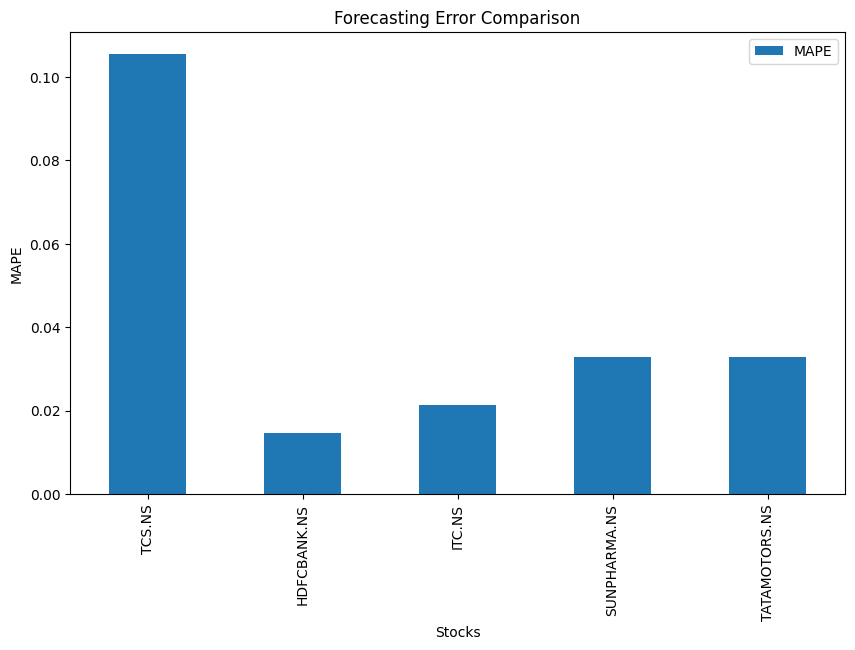

In [82]:
results_df.plot(
    x='Stock',
    y='MAPE',
    kind='bar',
    figsize=(10,6)
)

plt.title('Forecasting Error Comparison')

plt.xlabel('Stocks')

plt.ylabel('MAPE')

plt.show()